In [ ]:
import numpy as nd
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install python-docx

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from docx import Document
from docx.shared import Inches

In [ ]:
image_directory = "/content/drive/MyDrive/boroi dataset"
images = []

In [ ]:
for filename in os.listdir(image_directory):
  if filename.endswith(".jpg") or filename.endswith(".png"): # Example file extensions, adjust as needed
    img_path = os.path.join(image_directory, filename)
    img = cv2.imread(img_path)
    if img is not None: # Check if image loading was successful
      images.append(img)
    else:
      print(f"Failed to load image: {img_path}")

In [ ]:
import cv2
from PIL import Image

def crop_to_square(image_path, output_path):
    # Load image using OpenCV
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    height, width = image.shape[:2]

    # Determine the size of the square crop
    min_dim = min(height, width)
    start_x = (width - min_dim) // 2
    start_y = (height - min_dim) // 2

    # Crop the center square
    cropped_image = image[start_y:start_y + min_dim, start_x:start_x + min_dim]

    # Save output
    cv2.imwrite(output_path, cropped_image)
    print(f"Cropped image saved to {output_path}")

# Example usage
# crop_to_square("input.jpg", "output.jpg")


In [ ]:
IMG_SIZE = (299, 299)  # InceptionV3 input size
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.0001

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Correct preprocessing
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Correct preprocessing
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
input_path = image_directory

In [ ]:
train_generator = train_datagen.flow_from_directory(
    input_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Proper label format
    subset='training',
    shuffle=True
)

Found 1892 images belonging to 5 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    input_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 470 images belonging to 5 classes.


In [ ]:
# Load Pretrained InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base model

In [ ]:
# Custom Model Architecture
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
output_path = "/content/drive/MyDrive/Research dataset/Lotkon data set/output" # Example path, adjust accordingly

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

checkpoint = ModelCheckpoint(os.path.join(output_path, 'best_model.keras'),
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [20]:
# Train the Model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4441 - loss: 1.3952 
Epoch 1: val_accuracy improved from -inf to 0.45957, saving model to /content/drive/MyDrive/Research dataset/Lotkon data set/output/best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1641s 27s/step - accuracy: 0.4452 - loss: 1.3931 - val_accuracy: 0.4596 - val_loss: 1.3105
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.6328 - loss: 0.9716 
Epoch 2: val_accuracy did not improve from 0.45957
60/60 ━━━━━━━━━━━━━━━━━━━━ 1090s 18s/step - accuracy: 0.6328 - loss: 0.9719 - val_accuracy: 0.4383 - val_loss: 1.3504
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.6518 - loss: 0.9236 
Epoch 3: val_accuracy did not improve from 0.45957
60/60 ━━━━━━━━━━━━━━━━━━━━ 1091s 18s/step - accuracy: 0.6518 - loss: 0.9237 - val_accuracy: 0.4532 - val_loss: 1.3461
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6809 - loss: 0.8809 
Epoch 4: val_accuracy did not improve from 0.45957
60/6

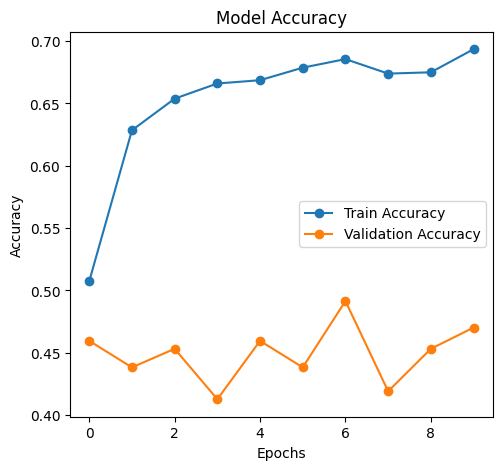

In [21]:
# Plot Accuracy & Loss Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [22]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

accuracy_loss_curve_path = os.path.join(output_path, 'accuracy_loss_curve.png')
plt.savefig(accuracy_loss_curve_path)
plt.close()

In [23]:
# Load Best Model for Evaluation
model.load_weights(os.path.join(output_path, 'best_model.keras'))

# Evaluate the Model
eval_result = model.evaluate(validation_generator)

# Generate Predictions and Classification Report
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

report = classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys()))

15/15 ━━━━━━━━━━━━━━━━━━━━ 175s 11s/step - accuracy: 0.5343 - loss: 1.1401
15/15 ━━━━━━━━━━━━━━━━━━━━ 201s 13s/step


In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
confusion_matrix_path = os.path.join(output_path, 'confusion_matrix.png')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(confusion_matrix_path)
plt.close()

In [25]:
# Create Word Document for Results
doc = Document()
doc.add_heading('Classification Report', 0)

In [26]:
# Model Performance Section
doc.add_heading('Model Performance', level=1)
doc.add_paragraph(f"Final Validation Loss: {eval_result[0]:.4f}")
doc.add_paragraph(f"Final Validation Accuracy: {eval_result[1]:.4f}")

In [27]:
# Classification Metrics Section
doc.add_heading('Classification Metrics', level=1)
doc.add_paragraph(report)

In [28]:
# Training History Section
doc.add_heading('Training History', level=1)
doc.add_picture(accuracy_loss_curve_path, width=Inches(6))

In [29]:
# Confusion Matrix Section
doc.add_heading('Confusion Matrix', level=1)
doc.add_picture(confusion_matrix_path, width=Inches(6))

In [30]:

# Save Document
doc.save(os.path.join(output_path, 'classification_report.docx'))

print("Training completed and results saved in Word document!")

Training completed and results saved in Word document!
